# BVA Sequence Decomposition And Noise Simulation

Decompose a list of same-dimension unitaries into one continuous star-topology pulse sequence, then simulate the full pulse train with deterministic line-phase terms and shot-to-shot detuning noise.

The carried-frame convention is

    D_final @ U_pulses = U_N @ ... @ U_2 @ U_1

If `apply_final_frame` is enabled in the simulation section, the notebook appends that final diagonal frame exactly.


In [493]:
import numpy as np
from numpy.linalg import norm

from U_decomp import unitary_to_G_rotations

np.set_printoptions(precision=4, suppress=True)


In [494]:
def qudit_qft(d, inverse=False):
    if d < 2:
        raise ValueError("d must be at least 2")
    omega = np.exp((-2j if inverse else 2j) * np.pi / d)
    j = np.arange(d).reshape((d, 1))
    k = np.arange(d).reshape((1, d))
    return omega ** (j * k) / np.sqrt(d)


def haar_unitary(n, rng=None):
    rng = np.random.default_rng(rng)
    X = (rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n))) / np.sqrt(2)
    Q, R = np.linalg.qr(X)
    d = np.diag(R)
    D = d / np.abs(d)
    return Q * D


def haar_su(n, rng=None):
    U = haar_unitary(n, rng)
    phi = np.angle(np.linalg.det(U)) / n
    return U * np.exp(-1j * phi)


def single_qudit_phase_oracle(hidden: int, d: int) -> np.ndarray:
    """
    Phase oracle for single-qudit BV:

        O_s |x> = omega^(s*x) |x>

    where hidden = s in {0, ..., d-1}.
    """
    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0 <= hidden < d):
        raise ValueError("hidden must be in {0, ..., d-1}")

    omega = np.exp(2j * np.pi / d)
    phases = np.array([omega ** (hidden * x) for x in range(d)], dtype=complex)
    return np.diag(phases)


def hadamard_1():
    return np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def hadamard_n(n):
    if n < 1:
        raise ValueError("n must be at least 1")
    H = hadamard_1()
    U = np.array([[1.0 + 0.0j]])
    for _ in range(n):
        U = np.kron(U, H)
    return U


def hidden_bits_from_value(hidden_value, n):
    if isinstance(hidden_value, str):
        if len(hidden_value) != n or any(bit not in "01" for bit in hidden_value):
            raise ValueError("hidden_value string must be an n-bit binary string")
        return np.array([int(bit) for bit in hidden_value], dtype=int)

    if isinstance(hidden_value, (list, tuple, np.ndarray)):
        bits = np.asarray(hidden_value, dtype=int)
        if bits.shape != (n,) or np.any((bits != 0) & (bits != 1)):
            raise ValueError("hidden_value array must be length n with entries 0 or 1")
        return bits

    hidden_value = int(hidden_value)
    if not (0 <= hidden_value < 2 ** n):
        raise ValueError("integer hidden_value must satisfy 0 <= hidden_value < 2**n")
    return np.array([int(bit) for bit in np.binary_repr(hidden_value, width=n)], dtype=int)


def bv_phase_oracle(hidden_value, n):
    bits = hidden_bits_from_value(hidden_value, n)
    dim = 2 ** n

    x_vals = np.arange(dim, dtype=np.uint64)
    bit_positions = np.arange(n - 1, -1, -1, dtype=np.uint64)
    x_bits = ((x_vals[:, None] >> bit_positions) & 1).astype(int)

    parity = (x_bits @ bits) % 2
    phases = 1.0 - 2.0 * parity
    return np.diag(phases.astype(complex))


def hidden_value_to_index(hidden_value, n):
    bits = hidden_bits_from_value(hidden_value, n)
    return int("".join(str(bit) for bit in bits), 2)


def build_bva_case(mode, hidden_value, dimension=None, n_qubits=None):
    if mode == "qudit_qft":
        if dimension is None:
            raise ValueError("dimension must be provided for mode='qudit_qft'")
        dimension = int(dimension)
        if dimension < 2:
            raise ValueError("dimension must be at least 2")
        hidden_index = int(hidden_value)
        if not (0 <= hidden_index < dimension):
            raise ValueError("hidden must satisfy 0 <= hidden < dimension")
        return {
            "dimension": dimension,
            "unitaries": [
                qudit_qft(dimension),
                single_qudit_phase_oracle(hidden_index, dimension),
                qudit_qft(dimension, inverse=True),
            ],
            "expected_output_index": hidden_index,
            "hidden_sweep_values": list(range(dimension)),
            "measured_state_labels": [str(index) for index in range(dimension)],
            "hidden_axis_labels": [str(index) for index in range(dimension)],
        }

    if mode == "qubit_hadamard":
        if n_qubits is None:
            raise ValueError("n_qubits must be provided for mode='qubit_hadamard'")
        n_qubits = int(n_qubits)
        if n_qubits < 1:
            raise ValueError("n_qubits must be at least 1")
        dimension = 2 ** n_qubits
        Hn = hadamard_n(n_qubits)
        expected_output_index = hidden_value_to_index(hidden_value, n_qubits)
        bit_labels = [np.binary_repr(index, width=n_qubits) for index in range(dimension)]
        ket_labels = [rf"$|{label}\rangle$" for label in bit_labels]
        return {
            "dimension": dimension,
            "unitaries": [
                Hn,
                bv_phase_oracle(hidden_value, n_qubits),
                Hn,
            ],
            "expected_output_index": expected_output_index,
            "hidden_sweep_values": bit_labels,
            "measured_state_labels": ket_labels,
            "hidden_axis_labels": ket_labels,
        }

    raise ValueError("mode must be either 'qudit_qft' or 'qubit_hadamard'")


def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state


In [495]:
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


def wrap_frame(z_frame):
    z = np.asarray(z_frame, dtype=float)
    return np.array([wrap_pi(value) for value in z], dtype=float)


def relative_frame(z_frame, reference=0):
    z = wrap_frame(z_frame)
    return wrap_frame(z - z[reference])


def virtual_z_diagonal(z_frame):
    return np.diag(np.exp(1j * np.asarray(z_frame, dtype=float)))


def ion_pulse_unitary(coupling, theta, phi, dim):
    i, j = coupling
    U = np.eye(dim, dtype=complex)
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -1j * np.exp(1j * phi) * s
    U[j, i] = -1j * np.exp(-1j * phi) * s
    return U


def rotation_matrix_to_pulse_parameters(G, tol=1e-10):
    G = np.asarray(G, dtype=complex)
    if G.ndim != 2 or G.shape[0] != G.shape[1]:
        raise ValueError("G must be square")

    dim = G.shape[0]
    candidates = [(p, q) for p in range(dim) for q in range(p + 1, dim)
                  if abs(G[p, q]) > tol or abs(G[q, p]) > tol]
    if len(candidates) != 1:
        raise ValueError(f"Expected exactly one coupled pair, found {candidates}")

    i, j = candidates[0]
    c = G[i, i]
    s = G[i, j]
    gamma = float(wrap_pi(np.angle(c)))
    theta = float(2.0 * np.arctan2(np.clip(np.abs(s), 0.0, 1.0), np.clip(np.abs(c), 0.0, 1.0)))
    phi = float((np.angle(s) - gamma + np.pi / 2) % (2 * np.pi))

    return {
        "coupling": (i, j),
        "theta": theta,
        "fraction": float(theta / np.pi),
        "phi": phi,
        "gamma": gamma,
    }


def minimize_gamma_for_step(step):
    alternate = dict(step)
    alternate["theta"] = float(2 * np.pi - step["theta"])
    alternate["fraction"] = float(alternate["theta"] / np.pi)
    alternate["phi"] = float((step["phi"] + np.pi) % (2 * np.pi))
    alternate["gamma"] = float(wrap_pi(step["gamma"] + np.pi))
    return alternate if abs(alternate["gamma"]) < abs(step["gamma"]) else dict(step)


def diagonal_phase_vector(V, tol=1e-8):
    V = np.asarray(V, dtype=complex)
    off_diag = V - np.diag(np.diag(V))
    if norm(off_diag) > tol:
        raise ValueError(f"Residual V is not diagonal enough: {norm(off_diag)}")

    diag = np.diag(V)
    if np.max(np.abs(np.abs(diag) - 1.0)) > 1e-7:
        raise ValueError("Residual V is diagonal but not unitary on the diagonal")

    return wrap_frame(np.angle(diag))


def sequence_target_unitary(unitaries):
    total = np.eye(unitaries[0].shape[0], dtype=complex)
    for U in unitaries:
        total = U @ total
    return total


def pulse_sequence_unitary(schedule, dim):
    U = np.eye(dim, dtype=complex)
    for step in schedule:
        U = ion_pulse_unitary(step["coupling"], step["theta"], step["phi_programmed"], dim) @ U
    return U


def decompose_unitary_sequence(unitaries, center=0, tol=1e-10, minimize_gamma=True, initial_frame=None):
    if len(unitaries) == 0:
        raise ValueError("Provide at least one unitary")

    unitary_list = [np.asarray(U, dtype=complex) for U in unitaries]
    dim = unitary_list[0].shape[0]

    for idx, U in enumerate(unitary_list, start=1):
        if U.ndim != 2 or U.shape[0] != U.shape[1]:
            raise ValueError(f"Unitary {idx} is not square")
        if U.shape[0] != dim:
            raise ValueError("All unitaries must have the same dimension")

    frame = np.zeros(dim, dtype=float) if initial_frame is None else np.asarray(initial_frame, dtype=float).copy()
    if frame.shape != (dim,):
        raise ValueError("initial_frame must have shape (dim,)")

    flat_schedule = []
    block_summaries = []

    for block_idx, U in enumerate(unitary_list, start=1):
        rotation_mats, V = unitary_to_G_rotations(U, center=center, tol=tol)
        V_phase = diagonal_phase_vector(V)

        incoming_frame = frame.copy()
        frame = wrap_frame(frame + V_phase)
        compile_frame_start = frame.copy()

        target_steps = [rotation_matrix_to_pulse_parameters(G.conj().T, tol=tol) for G in rotation_mats[::-1]]
        if minimize_gamma:
            target_steps = [minimize_gamma_for_step(step) for step in target_steps]

        for step_idx, step in enumerate(target_steps, start=1):
            i, j = step["coupling"]
            phi_programmed = float((step["phi"] - (frame[i] - frame[j])) % (2 * np.pi))

            flat_schedule.append({
                "block": block_idx,
                "step_in_block": step_idx,
                "coupling": step["coupling"],
                "theta": step["theta"],
                "fraction": step["fraction"],
                "phi_programmed": phi_programmed,
                "phi_physical": step["phi"],
                "gamma": step["gamma"],
                "frame_before": frame.copy(),
            })

            frame[i] += step["gamma"]
            frame[j] -= step["gamma"]
            frame = wrap_frame(frame)
            flat_schedule[-1]["frame_after"] = frame.copy()

        block_summaries.append({
            "block": block_idx,
            "incoming_frame": incoming_frame,
            "residual_from_V": V_phase,
            "compile_frame_start": compile_frame_start,
            "outgoing_frame": frame.copy(),
            "pulse_count": len(target_steps),
        })

    return flat_schedule, frame, block_summaries


## Choose algorith mode and decomp strat

In [496]:
# Choose one of:
algorithm_mode = "qudit_qft"
# algorithm_mode = "qubit_hadamard"

# algorithm_mode = "qudit_qft"

if algorithm_mode == "qudit_qft":
    dimension = 7
    hidden = 4
    case_kwargs = {"dimension": dimension}
elif algorithm_mode == "qubit_hadamard":
    n_qubits = 3
    hidden = "101"
    case_kwargs = {"n_qubits": n_qubits}
else:
    raise ValueError("algorithm_mode must be 'qudit_qft' or 'qubit_hadamard'")

bva_case = build_bva_case(algorithm_mode, hidden_value=hidden, **case_kwargs)
dimension = bva_case["dimension"]
unitaries = bva_case["unitaries"]
expected_output_index = bva_case["expected_output_index"]
hidden_sweep_values = bva_case["hidden_sweep_values"]
measured_state_labels = bva_case["measured_state_labels"]
hidden_axis_labels = bva_case["hidden_axis_labels"]

print("algorithm_mode =", algorithm_mode)
print("dimension =", dimension)
print("hidden =", hidden)
print("expected_output_index =", expected_output_index)

center = 0
tol = 1e-10
minimize_gamma = False
initial_frame = None  # Or set a numpy array if you want to continue from an existing residual frame.


algorithm_mode = qudit_qft
dimension = 7
hidden = 4
expected_output_index = 4


In [497]:
flat_schedule, final_frame, block_summaries = decompose_unitary_sequence(
    unitaries,
    center=center,
    tol=tol,
    minimize_gamma=minimize_gamma,
    initial_frame=initial_frame,
)

couplings = [step["coupling"] for step in flat_schedule]
thetas = [step["theta"] for step in flat_schedule]
fractions = [step["fraction"] for step in flat_schedule]
phases = [step["phi_programmed"] for step in flat_schedule]
gammas = [step["gamma"] for step in flat_schedule]
blocks = [step["block"] for step in flat_schedule]
steps_in_block = [step["step_in_block"] for step in flat_schedule]

print(f"number of input unitaries: {len(unitaries)}")
print(f"total pulse count: {len(flat_schedule)}")
print("final residual frame (wrapped):")
print(wrap_frame(final_frame))
print("final residual frame relative to level 0:")
print(relative_frame(final_frame, reference=0))

print("\nPer-block summary:")
for summary in block_summaries:
    print(f"block {summary['block']:2d}: pulses={summary['pulse_count']}")
    print("  residual_from_V          =", wrap_frame(summary['residual_from_V']))
    print("  compile_frame_start      =", wrap_frame(summary['compile_frame_start']))
    print("  outgoing_frame           =", wrap_frame(summary['outgoing_frame']))

print("\nFull flat schedule:")
for step in flat_schedule:
    print(
        f"block {step['block']:2d}, step {step['step_in_block']:2d}: "
        f"coupling={step['coupling']}, theta={step['theta']:.6f} rad, "
        f"fraction={step['fraction']:.6f}, phi_programmed={step['phi_programmed']:.6f} rad, "
        f"gamma={step['gamma']:+.6f} rad"
    )


number of input unitaries: 3
total pulse count: 42
final residual frame (wrapped):
[ 0.     -2.6928  0.8976 -1.7952  1.7952 -0.8976  2.6928]
final residual frame relative to level 0:
[ 0.     -2.6928  0.8976 -1.7952  1.7952 -0.8976  2.6928]

Per-block summary:
block  1: pulses=21
  residual_from_V          = [1.5708 0.     0.     0.     0.     0.     0.    ]
  compile_frame_start      = [1.5708 0.     0.     0.     0.     0.     0.    ]
  outgoing_frame           = [ 2.184   2.2252  2.7657  1.198   1.3938 -2.8103  0.8976]
block  2: pulses=0
  residual_from_V          = [ 0.     -2.6928  0.8976 -1.7952  1.7952 -0.8976  2.6928]
  compile_frame_start      = [ 2.184  -0.4676 -2.6199 -0.5972 -3.0942  2.5753 -2.6928]
  outgoing_frame           = [ 2.184  -0.4676 -2.6199 -0.5972 -3.0942  2.5753 -2.6928]
block  3: pulses=21
  residual_from_V          = [-1.5708  0.      0.      0.      0.      0.      0.    ]
  compile_frame_start      = [ 0.6132 -0.4676 -2.6199 -0.5972 -3.0942  2.5753 -2.6928

In [498]:
print("couplings =", couplings)
print("fractions =", fractions)
print("thetas =", thetas)
print("phases =", phases)
print("gammas =", gammas)
print("blocks =", blocks)
print("steps_in_block =", steps_in_block)
print("final_frame =", wrap_frame(final_frame))
print("final_frame_relative =", relative_frame(final_frame, reference=0))


couplings = [(0, 1), (0, 2), (0, 1), (0, 3), (0, 2), (0, 1), (0, 4), (0, 3), (0, 2), (0, 1), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 1), (0, 2), (0, 1), (0, 3), (0, 2), (0, 1), (0, 4), (0, 3), (0, 2), (0, 1), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1)]
fractions = [0.8465478283245834, 0.5984353648431473, 0.5701087109521663, 0.6700275865012124, 0.2764363887454224, 0.5846689049540825, 0.6902410505036123, 0.34684484630626994, 0.43065859202894896, 0.4379431618257981, 0.695528582373969, 0.3636587637623627, 0.4122349355609201, 0.421984516765907, 0.32889278736067823, 0.7532482855711499, 0.26772047280123024, 0.29516723530086675, 0.33333333333333354, 0.3918265520306074, 0.5000000000000001, 0.8465478283245834, 0.5984353648431473, 0.5701087109521663, 0.6700275865012124, 0.2764363887454224, 0.5846689049540825, 0.6902410505036123, 0.34684484630626994, 0.43065859202894896, 0.4379431618257981, 0.6955285823

In [499]:
print(sum(fractions))

20.43101579969254


In [500]:
dim = unitaries[0].shape[0]
U_pulses = pulse_sequence_unitary(flat_schedule, dim)
U_target = sequence_target_unitary(unitaries)
U_exact = virtual_z_diagonal(final_frame) @ U_pulses

print("pulse-only error vs full target:", norm(U_pulses - U_target))
print("pulse-plus-final-frame error vs full target:", norm(U_exact - U_target))


pulse-only error vs full target: 3.7416573867739435
pulse-plus-final-frame error vs full target: 5.8472909143847534e-15


# Temp storage

## Pulse Simulation

The cells below keep the decomposition output self-contained. They convert the pulse list into durations, add optional deterministic line-noise phases, sample shot-to-shot detuning noise, and simulate the full state evolution.

Assumptions:
- `pulse_sensitivities_mhz_per_g` is aligned with the pulse order.
- sensitivities are given in `MHz/G`.
- pi-times are specified directly in microseconds.


In [501]:
def parse_string_to_int_list(s):
    s = s.strip()
    if s.startswith('[') and s.endswith(']'):
        inside = s[1:-1].strip()
        parts = inside.split(',')
        return [int(x) for x in parts]
    else:
        return [int(s)]

def build_transitions_list(index_to_str_map, couplings):
    transitions_list = []
    for (start_idx, end_idx) in couplings:
        left_list  = parse_string_to_int_list(index_to_str_map[start_idx])
        right_list = parse_string_to_int_list(index_to_str_map[end_idx])
        transitions_list.append(left_list + right_list)
    return transitions_list
transition_strengths = np.loadtxt('Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p209.txt', delimiter=',')
def compute_pi_times(pi_t, ref_transitions = np.array([
        transition_strengths[23, 0], transition_strengths[14, 0],
        transition_strengths[17, 4], transition_strengths[16, 4], transition_strengths[15, 4]
    ])):
    transition_strengths = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p209.txt', delimiter=','
    )
    transition_strengths[transition_strengths == 0] = np.nan

    # pi_t = np.array([19.470, 35.554, 41.166, 30.108, 39.326])
    strengths = ref_transitions

    factors = np.array(pi_t) * strengths
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros((24, 5))
    for i in range(np.shape(transition_strengths)[0]):
        for j in range(np.shape(transition_strengths)[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    
    return pi_times

def get_pi_times(transitions, pi_t = np.array([25, 25, 100, 25, 25]),ref_transitions = np.array([
        transition_strengths[21, 2], transition_strengths[14, 0],
        transition_strengths[5, 2], transition_strengths[16, 4], transition_strengths[15, 4]
    ])):
    matrix = compute_pi_times(pi_t, ref_transitions)
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    for transition in transitions:
        if transition[1] == 0 and transition[2] == 0:
            pi_times_list.append(1e6)
            continue
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
    
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(1e6)

    return pi_times_list
sens_matrix = np.loadtxt('Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p2079.txt', delimiter=',')
def get_values_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out

mappings = {0: '0', 1: '[3, -1]', 2: '[4, 1]', 3: '[2, 0]', 4: '[3, 0]', 5: '[4, 0]', 6: '[3, 1]', 7: '[4, -1]'}
mappings = {
    0: '0',
    1: '[4, -2]',
    2: '[3, 1]',
    3: '[4, -1]',
    4: '[3, 0]',
    5: '[3, 2]',
    6: '[4, 0]',
    7: '[2, -2]',
    8: '[2, 0]',
    9: '[2, 2]',
    10: '[4, 1]',
    11: '[3, -1]',
    12: '[1, 1]',
    13: '[2, -1]',
    14: '[1, -1]',
    15: '[2, 1]',
}

# mappings = {0: '0', 1: '[3, -1]', 2: '[4, 1]', 3: '[2, 0]', 4: '[3, 0]', 5: '[4, 0]', 6: '[3, 1]', 7: '[4, -1]'}

pulse_train_list = build_transitions_list(mappings, couplings)
pulse_pi_times_list = get_pi_times(pulse_train_list, pi_t = np.array([23.9, 25.491, 98.8, 25.836, 32.11])) #list of pi times for each transition in the pulse train
pulse_sensitivities_list = get_values_from_matrix(pulse_train_list, sens_matrix) # list of sensitivities for each transition in the pulse train 
# print(pulse_sensitivities_list)


In [502]:
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import rcParams
import json

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True



def state_populations(state):
    state = np.asarray(state, dtype=complex)
    return np.abs(state) ** 2


def coupling_key(coupling):
    return tuple(int(value) for value in coupling)


def resolve_pi_times_us(couplings, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    if per_pulse_pi_time_us is not None:
        pi_times_us = np.asarray(per_pulse_pi_time_us, dtype=float)
        if pi_times_us.shape != (len(couplings),):
            raise ValueError("per_pulse_pi_time_us must have length equal to the pulse count")
        return pi_times_us
    default_pi_time_us = float(default_pi_time_us)
    pi_time_by_coupling_us = {} if pi_time_by_coupling_us is None else {
        coupling_key(key): float(value) for key, value in pi_time_by_coupling_us.items()
    }
    return np.asarray([pi_time_by_coupling_us.get(coupling, default_pi_time_us) for coupling in couplings], dtype=float)


def pulse_durations_us_from_thetas(thetas, pi_times_us):
    thetas = np.asarray(thetas, dtype=float)
    pi_times_us = np.asarray(pi_times_us, dtype=float)
    if thetas.shape != pi_times_us.shape:
        raise ValueError("thetas and pi_times_us must have the same shape")
    return thetas * pi_times_us / np.pi


def pulse_timing_us(durations_us):
    durations_us = np.asarray(durations_us, dtype=float)
    t_end = np.cumsum(durations_us)
    t_start = np.concatenate(([0.0], t_end[:-1])) if len(durations_us) else np.asarray([], dtype=float)
    return np.column_stack((t_start, t_end)) if len(durations_us) else np.empty((0, 2), dtype=float)


def default_line_noise_model():
    return {"B0_mG": 0.2289, "harmonics": [(60.0, -0.2791, 1.0002), (180.0, -0.0774, -0.2650)]}


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    harmonics = line_model.get("harmonics", [])
    freqs_hz = np.asarray([item[0] for item in harmonics], dtype=float)
    amplitudes_mG = np.asarray([item[1] for item in harmonics], dtype=float)
    phases_rad = np.asarray([item[2] for item in harmonics], dtype=float)
    return float(line_model.get("B0_mG", 0.0)), freqs_hz, amplitudes_mG, phases_rad


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_mG, dtype=float)
    reference_mG = B0_mG
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    reference_mG = B0_mG + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_mG - reference_mG) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref="start", enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros
    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")
    area_Gs = -line_field_primitive_Gs(t_refs_sec, line_model=line_model)
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


In [503]:
from functools import lru_cache
from scipy.special import voigt_profile


def laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s):
    sigma_hz = np.sqrt(2.0) / float(gaussian_T_s)
    gamma_hz = 1.0 / float(lorentzian_L_s)
    return sigma_hz, gamma_hz


@lru_cache(maxsize=None)
def _cached_voigt_cdf_grid(sigma_hz, gamma_hz, x_min_hz, x_max_hz, num_points):
    sigma_hz = float(sigma_hz)
    gamma_hz = float(gamma_hz)
    x_min_hz = float(x_min_hz)
    x_max_hz = float(x_max_hz)
    num_points = int(num_points)
    if num_points < 2:
        raise ValueError('num_points must be at least 2')
    if not x_min_hz < x_max_hz:
        raise ValueError('x_min_hz must be less than x_max_hz')

    x_vals = np.linspace(x_min_hz, x_max_hz, num_points, dtype=float)
    dx = x_vals[1] - x_vals[0]
    profile_vals = voigt_profile(x_vals, sigma_hz, gamma_hz)
    cdf = np.cumsum(profile_vals) * dx
    if not np.isfinite(cdf[-1]) or cdf[-1] <= 0.0:
        raise ValueError('Voigt CDF normalization failed; check sigma/gamma and sampling window')
    cdf /= cdf[-1]
    cdf = np.maximum.accumulate(cdf)
    cdf[-1] = 1.0
    return x_vals, cdf


def sample_voigt_hz(rng=None, sigma_hz=0.0, gamma_hz=0.0, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    sigma_hz = max(float(sigma_hz), 0.0)
    gamma_hz = max(float(gamma_hz), 0.0)
    if sigma_hz == 0.0 and gamma_hz == 0.0:
        if size is None:
            return 0.0
        return np.zeros(size, dtype=float)

    x_vals, cdf = _cached_voigt_cdf_grid(sigma_hz, gamma_hz, float(x_min_hz), float(x_max_hz), int(num_points))
    u = generator.random(size=size)
    samples = np.interp(u, cdf, x_vals)
    if size is None:
        return float(samples)
    return samples


def sample_frequency_calibration_error_hz(rng=None, sigma_hz=0.0, hwhm_hz=14.976, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=float(hwhm_hz),
        size=size,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_laser_noise_hz(rng=None, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    sigma_hz, gamma_hz = laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s)
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=gamma_hz,
        size=None,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_rabi_frequency_scale(rng=None, std_fraction=0.037):
    generator = np.random.default_rng() if rng is None else rng
    return 1.0 + float(std_fraction) * generator.normal()


def sample_line_signal_field_offset_g(rng=None, std_g=50e-6):
    generator = np.random.default_rng() if rng is None else rng
    return float(std_g) * generator.normal()


def line_signal_field_noise_corrections(durations_us, sensitivities_mhz_per_g, line_field_offset_g=0.0, t_ref="start"):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if len(durations_us) == 0 or float(line_field_offset_g) == 0.0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    area_Gs = float(line_field_offset_g) * t_refs_sec
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = float(line_field_offset_g) * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


def build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g, atol=1e-12):
    couplings = [coupling_key(coupling) for coupling in couplings]
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    if pulse_sensitivities_mhz_per_g.shape != (len(couplings),):
        raise ValueError("pulse_sensitivities_mhz_per_g must have length equal to the pulse count")
    unique_couplings, unique_sensitivities, inverse_indices, index_lookup = [], [], [], {}
    for coupling, sensitivity in zip(couplings, pulse_sensitivities_mhz_per_g):
        if coupling not in index_lookup:
            index_lookup[coupling] = len(unique_couplings)
            unique_couplings.append(coupling)
            unique_sensitivities.append(float(sensitivity))
        else:
            existing_index = index_lookup[coupling]
            if not np.isclose(unique_sensitivities[existing_index], float(sensitivity), atol=atol, rtol=0.0):
                raise ValueError(
                    f"Coupling {coupling} appears with multiple sensitivity values: "
                    f"{unique_sensitivities[existing_index]} and {float(sensitivity)}"
                )
        inverse_indices.append(index_lookup[coupling])
    return {"couplings": unique_couplings, "sensitivities_mhz_per_g": np.asarray(unique_sensitivities, dtype=float), "inverse_indices": np.asarray(inverse_indices, dtype=int)}


def sample_unique_coupling_detunings_mhz(unique_sensitivities_mhz_per_g, rng=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    unique_sensitivities_mhz_per_g = np.asarray(unique_sensitivities_mhz_per_g, dtype=float)
    num_couplings = len(unique_sensitivities_mhz_per_g)

    shared_calibration_noise_hz = calibration_scale * sample_frequency_calibration_error_hz(
        generator,
        sigma_hz=calibration_noise_sigma_hz,
        hwhm_hz=calibration_noise_hwhm_hz,
        size=None,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    calibration_noise_mhz = np.full(num_couplings, shared_calibration_noise_hz * 1e-6, dtype=float)

    magnetic_field_sample_g = magnetic_scale * generator.normal(0.0, magnetic_field_std_g)
    magnetic_noise_mhz = magnetic_field_sample_g * unique_sensitivities_mhz_per_g

    shared_laser_noise_hz = laser_scale * sample_laser_noise_hz(
        generator,
        gaussian_T_s=gaussian_T_s,
        lorentzian_L_s=lorentzian_L_s,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    laser_noise_mhz = np.full(num_couplings, shared_laser_noise_hz * 1e-6, dtype=float)
    return calibration_noise_mhz + magnetic_noise_mhz + laser_noise_mhz


def simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state, final_frame=None, apply_final_frame=False, line_phase_offsets_rad=None, line_detunings_mhz=None, global_detuning_mhz_by_coupling=None, rabi_frequency_scales=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    durations_us = np.asarray(durations_us, dtype=float)
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_pulses = len(couplings)
    if durations_us.shape != (num_pulses,) or thetas.shape != (num_pulses,) or programmed_phases.shape != (num_pulses,):
        raise ValueError("couplings, durations_us, thetas, and programmed_phases must all have the same length")
    line_phase_offsets_rad = np.zeros(num_pulses, dtype=float) if line_phase_offsets_rad is None else np.asarray(line_phase_offsets_rad, dtype=float)
    line_detunings_mhz = np.zeros(num_pulses, dtype=float) if line_detunings_mhz is None else np.asarray(line_detunings_mhz, dtype=float)
    rabi_frequency_scales = np.ones(num_pulses, dtype=float) if rabi_frequency_scales is None else np.asarray(rabi_frequency_scales, dtype=float)
    if line_phase_offsets_rad.shape != (num_pulses,) or line_detunings_mhz.shape != (num_pulses,) or rabi_frequency_scales.shape != (num_pulses,):
        raise ValueError("line-phase, line-detuning, and rabi-scale arrays must have length equal to the pulse count")
    dim = initial_state.shape[0]
    state = initial_state.copy()
    H_det_global = np.zeros((dim, dim), dtype=complex)
    if global_detuning_mhz_by_coupling is not None:
        for coupling, delta_mhz in global_detuning_mhz_by_coupling.items():
            i, j = coupling_key(coupling)
            delta_rad_per_us = 2.0 * np.pi * float(delta_mhz)
            H_det_global[i, i] += 0.5 * delta_rad_per_us
            H_det_global[j, j] -= 0.5 * delta_rad_per_us
    total_phases = programmed_phases + line_phase_offsets_rad
    for (i, j), duration_us, theta, total_phase, delta_line_mhz, rabi_scale in zip(couplings, durations_us, thetas, total_phases, line_detunings_mhz, rabi_frequency_scales):
        if duration_us <= 0.0:
            continue
        omega_rad_per_us = float(rabi_scale) * theta / duration_us
        H_pulse = H_det_global.copy()
        delta_line_rad_per_us = 2.0 * np.pi * float(delta_line_mhz)
        H_pulse[i, i] += 0.5 * delta_line_rad_per_us
        H_pulse[j, j] -= 0.5 * delta_line_rad_per_us
        phase_factor = np.exp(1j * total_phase)
        H_pulse[i, j] += 0.5 * omega_rad_per_us * phase_factor
        H_pulse[j, i] += 0.5 * omega_rad_per_us * np.conj(phase_factor)
        state = expm(-1j * H_pulse * duration_us) @ state
    if apply_final_frame and final_frame is not None:
        state = virtual_z_diagonal(final_frame) @ state
    return state


def monte_carlo_schedule(couplings, thetas, programmed_phases, initial_state, pulse_sensitivities_mhz_per_g, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None, final_frame=None, apply_final_frame=True, use_line_noise=False, line_model=None, line_reference="start", num_shots=100, rng_seed=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, laser_gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, laser_lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000, rabi_frequency_std_fraction=0.037, line_signal_noise_std_g=50e-6, target_state=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_shots = int(num_shots)
    if num_shots < 1:
        raise ValueError("num_shots must be at least 1")
    pi_times_us = resolve_pi_times_us(couplings, default_pi_time_us=default_pi_time_us, pi_time_by_coupling_us=pi_time_by_coupling_us, per_pulse_pi_time_us=per_pulse_pi_time_us)
    durations_us = pulse_durations_us_from_thetas(thetas, pi_times_us)
    timing_us = pulse_timing_us(durations_us)
    base_line_phase_offsets_rad, base_line_detunings_mhz, line_reference_times_s = compute_line_phase_corrections(durations_us, pulse_sensitivities_mhz_per_g, line_model=line_model, t_ref=line_reference, enabled=use_line_noise)
    unique_noise_inputs = build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g)
    generator = np.random.default_rng(rng_seed)
    noiseless_state = simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state=initial_state, final_frame=final_frame, apply_final_frame=apply_final_frame, line_phase_offsets_rad=base_line_phase_offsets_rad, line_detunings_mhz=base_line_detunings_mhz, global_detuning_mhz_by_coupling={coupling: 0.0 for coupling in unique_noise_inputs["couplings"]}, rabi_frequency_scales=np.ones(len(couplings), dtype=float))
    shot_populations, shot_fidelities = [], []
    for _ in range(num_shots):
        sampled_noise = sample_unique_coupling_detunings_mhz(
            unique_noise_inputs["sensitivities_mhz_per_g"],
            rng=generator,
            calibration_scale=calibration_scale,
            magnetic_scale=magnetic_scale,
            laser_scale=laser_scale,
            calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
            calibration_noise_sigma_hz=calibration_noise_sigma_hz,
            magnetic_field_std_g=magnetic_field_std_g,
            gaussian_T_s=laser_gaussian_T_s,
            lorentzian_L_s=laser_lorentzian_L_s,
            voigt_x_min_hz=voigt_x_min_hz,
            voigt_x_max_hz=voigt_x_max_hz,
            voigt_num_points=voigt_num_points,
        )
        detuning_map = {coupling: detuning_mhz for coupling, detuning_mhz in zip(unique_noise_inputs["couplings"], sampled_noise)}

        shared_rabi_scale = sample_rabi_frequency_scale(generator, std_fraction=rabi_frequency_std_fraction)
        rabi_frequency_scales = np.full(len(couplings), shared_rabi_scale, dtype=float)

        line_field_offset_g = sample_line_signal_field_offset_g(generator, std_g=line_signal_noise_std_g)
        line_noise_phases_rad, line_noise_detunings_mhz, _ = line_signal_field_noise_corrections(
            durations_us,
            pulse_sensitivities_mhz_per_g,
            line_field_offset_g=line_field_offset_g,
            t_ref=line_reference,
        )

        final_state = simulate_schedule_state(
            couplings,
            durations_us,
            thetas,
            programmed_phases,
            initial_state=initial_state,
            final_frame=final_frame,
            apply_final_frame=apply_final_frame,
            line_phase_offsets_rad=base_line_phase_offsets_rad + line_noise_phases_rad,
            line_detunings_mhz=base_line_detunings_mhz + line_noise_detunings_mhz,
            global_detuning_mhz_by_coupling=detuning_map,
            rabi_frequency_scales=rabi_frequency_scales,
        )
        shot_populations.append(state_populations(final_state))
        if target_state is not None:
            shot_fidelities.append(float(np.real_if_close(abs(np.vdot(target_state, final_state)) ** 2)))
    shot_populations = np.asarray(shot_populations, dtype=float)
    mean_populations = np.mean(shot_populations, axis=0)
    std_populations = np.std(shot_populations, axis=0, ddof=1) if num_shots > 1 else np.zeros_like(mean_populations)
    shot_fidelities = np.asarray(shot_fidelities, dtype=float)
    mean_fidelity = float(np.mean(shot_fidelities)) if len(shot_fidelities) else np.nan
    std_fidelity = float(np.std(shot_fidelities, ddof=1)) if len(shot_fidelities) > 1 else (0.0 if len(shot_fidelities) == 1 else np.nan)
    return {"pi_times_us": pi_times_us, "pulse_durations_us": durations_us, "timing_us": timing_us, "line_phase_offsets_rad": base_line_phase_offsets_rad, "line_detunings_mhz": base_line_detunings_mhz, "line_reference_times_s": line_reference_times_s, "noiseless_state": noiseless_state, "shot_populations": shot_populations, "mean_populations": mean_populations, "std_populations": std_populations, "shot_fidelities": shot_fidelities, "mean_fidelity": mean_fidelity, "std_fidelity": std_fidelity}


In [504]:

import io


def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, 'r') as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=' ')
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals


def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=None):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for freq_hz, amplitude_mG, phase_rad in zip(freqs, A_vals, phi_vals):
        y = y + amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_arr + phase_rad)
    return y


def default_line_noise_model(param_file=r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    return {
        'B0_mG': 0.2289,
        'A60_mG': -0.2791,
        'phi60_rad': 1.0002,
        'A180_mG': -0.0774,
        'phi180_rad': -0.2650,
        'param_file': param_file,
    }


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    return _get_line_params(
        line_model.get('param_file'),
        line_model.get('B0_mG', 0.2289),
        line_model.get('A60_mG', -0.2791),
        line_model.get('phi60_rad', 1.0002),
        line_model.get('A180_mG', -0.0774),
        line_model.get('phi180_rad', -0.2650),
    )


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_use, dtype=float)
    reference_mG = B0_use
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    B_line_0 = B0_use + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_use - B_line_0) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref='start', enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError('durations_us and sensitivities_mhz_per_g must have the same shape')
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6

    if t_ref == 'start':
        t_refs_sec = pulse_starts_sec
    elif t_ref == 'end':
        t_refs_sec = pulse_ends_sec
    elif t_ref == 'mid':
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    # pulse_interval_area_Gs = line_field_primitive_Gs(pulse_ends_sec, line_model=line_model) - line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    pulse_interval_area_Gs = line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    area_Gs = pulse_interval_area_Gs
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


## Noise Values

In [505]:

initial_state = basis_state(0, unitaries[0].shape[0])
expected_output_index = int(expected_output_index) if "expected_output_index" in globals() else None

default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
per_pulse_pi_time_us = np.asarray(pulse_pi_times_list, dtype=float)

pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_list, dtype=float)

use_line_noise = False
line_model = default_line_noise_model(param_file=r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt')
line_reference = "start"

num_shots = 200
rng_seed = np.random.SeedSequence().entropy
calibration_scale = 1.0
magnetic_scale = 1.0
laser_scale = 1.0
calibration_noise_hwhm_hz = 15
calibration_noise_sigma_hz = 0.0
magnetic_field_std_g = 11.13e-6
laser_gaussian_T_s = 2 * np.pi * 1521.1210128727998e-6
laser_lorentzian_L_s = 2 * np.pi * 3038.1329363025798e-6
voigt_x_min_hz = -1000.0
voigt_x_max_hz = 1000.0
voigt_num_points = 100000
rabi_frequency_std_fraction = 0.037
line_signal_noise_std_g = 0*50e-6

apply_final_frame = False


In [506]:
# Scratch cell intentionally left blank.
# Configure the BV mode in the user-input cell above.


## Call to  pipeline and results

In [507]:

hidden_values = list(hidden_sweep_values)
hidden_vs_measured = np.zeros((dimension, dimension), dtype=float)
hidden_final_frames = np.zeros((dimension, dimension), dtype=float)

for row_index, hidden_value in enumerate(hidden_values):
    hidden_case = build_bva_case(algorithm_mode, hidden_value=hidden_value, **case_kwargs)
    hidden_unitaries = hidden_case["unitaries"]

    hidden_schedule, hidden_final_frame, _ = decompose_unitary_sequence(
        hidden_unitaries,
        center=center,
        tol=tol,
        minimize_gamma=minimize_gamma,
        initial_frame=initial_frame,
    )
    hidden_couplings = [step['coupling'] for step in hidden_schedule]
    hidden_thetas = [step['theta'] for step in hidden_schedule]
    hidden_phases = [step['phi_programmed'] for step in hidden_schedule]

    hidden_pulse_train = build_transitions_list(mappings, hidden_couplings)
    hidden_pi_times = np.asarray(get_pi_times(hidden_pulse_train), dtype=float)
    hidden_sensitivities = np.asarray(get_values_from_matrix(hidden_pulse_train, sens_matrix), dtype=float)
    hidden_target_state = sequence_target_unitary(hidden_unitaries) @ initial_state

    hidden_result = monte_carlo_schedule(
        couplings=hidden_couplings,
        thetas=hidden_thetas,
        programmed_phases=hidden_phases,
        initial_state=initial_state,
        pulse_sensitivities_mhz_per_g=hidden_sensitivities,
        default_pi_time_us=default_pi_time_us,
        per_pulse_pi_time_us=hidden_pi_times,
        final_frame=wrap_frame(hidden_final_frame),
        apply_final_frame=apply_final_frame,
        use_line_noise=use_line_noise,
        line_model=line_model,
        line_reference=line_reference,
        num_shots=num_shots,
        rng_seed=None if rng_seed is None else int(rng_seed) + row_index,
        calibration_scale=calibration_scale,
        magnetic_scale=magnetic_scale,
        laser_scale=laser_scale,
        calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
        calibration_noise_sigma_hz=calibration_noise_sigma_hz,
        magnetic_field_std_g=magnetic_field_std_g,
        laser_gaussian_T_s=laser_gaussian_T_s,
        laser_lorentzian_L_s=laser_lorentzian_L_s,
        voigt_x_min_hz=voigt_x_min_hz,
        voigt_x_max_hz=voigt_x_max_hz,
        voigt_num_points=voigt_num_points,
        rabi_frequency_std_fraction=rabi_frequency_std_fraction,
        line_signal_noise_std_g=line_signal_noise_std_g,
        target_state=hidden_target_state,
    )

    hidden_vs_measured[row_index] = hidden_result['mean_populations']
    hidden_final_frames[row_index] = relative_frame(hidden_final_frame, reference=0)


def format_state_label(label):
    label_str = str(label)
    return f'{label_str}'


if algorithm_mode == "qudit_qft" and 'mappings' in globals():
    measured_labels = [
        format_state_label(mappings.get(index, measured_state_labels[index]))
        for index in range(dimension)
    ]
else:
    measured_labels = [format_state_label(label) for label in measured_state_labels]

hidden_labels = [format_state_label(label) for label in hidden_axis_labels]
recovered_indices = np.argmax(hidden_vs_measured, axis=1)
recovered_labels = [measured_labels[index] for index in recovered_indices]
hidden_vs_measured_percent = 100.0 * hidden_vs_measured


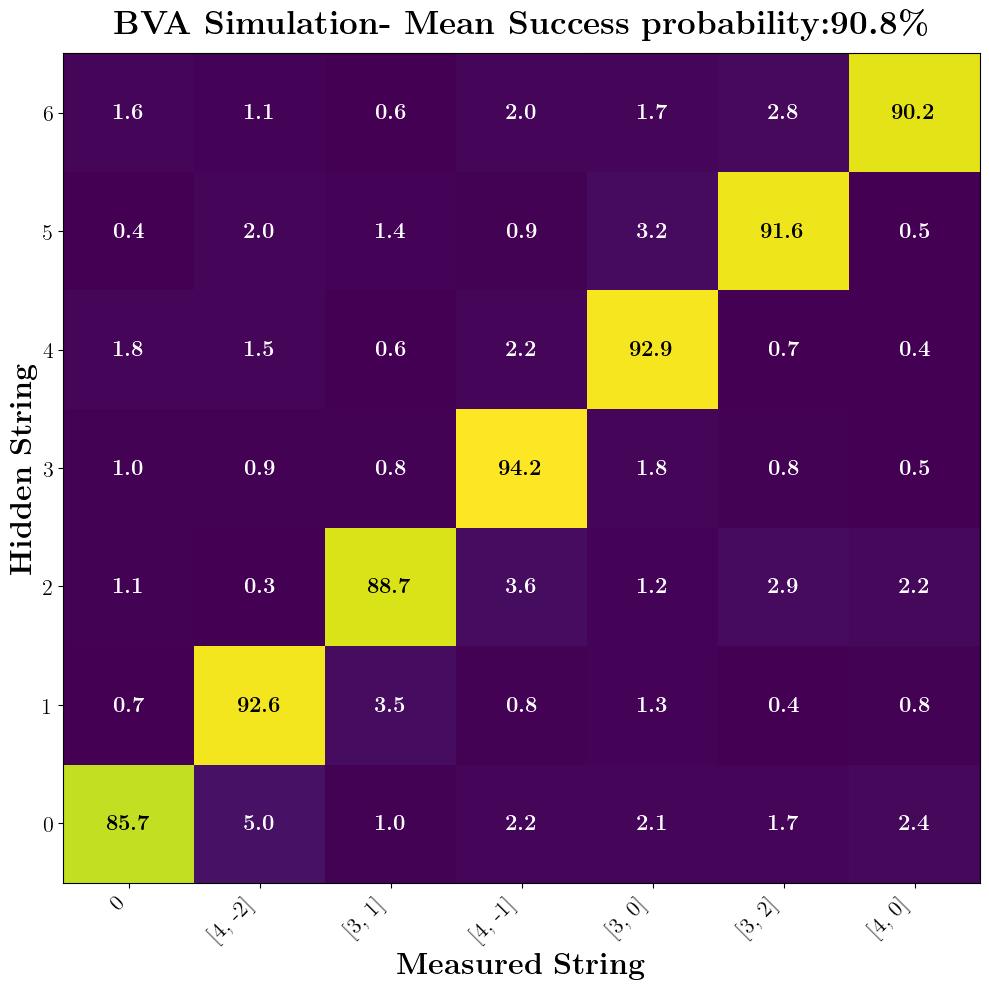

Recovered measured indices by hidden state: [0, 1, 2, 3, 4, 5, 6]
Recovered measured labels by hidden state: ['0', '[4, -2]', '[3, 1]', '[4, -1]', '[3, 0]', '[3, 2]', '[4, 0]']


In [508]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(
    hidden_vs_measured_percent,
    origin='lower',
    aspect='auto',
    # vmin=0.0,
    # vmax=100.0,
    cmap='viridis',
)

ax.set_xticks(np.arange(dimension))
ax.set_yticks(np.arange(dimension))
ax.set_xticklabels(measured_labels, rotation=45, ha='right', fontsize=16)
ax.set_yticklabels(hidden_labels, fontsize=16)
ax.set_xlabel(r'\textbf{Measured String}', fontsize=22)
ax.set_ylabel(r'\textbf{Hidden String}', fontsize=22)
ax.set_title(r'\textbf{BVA Simulation- Mean Success probability:}' + rf'\boldmath${np.mean(np.diag(hidden_vs_measured_percent)):.1f}\%$', fontsize=24, pad=14)
ax.tick_params(axis='both', which='major', labelsize=16)

for row_index in range(dimension):
    for col_index in range(dimension):
        value_percent = hidden_vs_measured_percent[row_index, col_index]
        if value_percent < 0.05:
            continue
        text_color = 'black' if value_percent >= 18.0 else 'white'
        ax.text(
            col_index,
            row_index,
            rf'\textbf{{{value_percent:.1f}}}',
            ha='center',
            va='center',
            color=text_color,
            fontsize=16,
            fontweight='bold',
        )

plt.tight_layout()
plt.show()

print('Recovered measured indices by hidden state:', recovered_indices.tolist())
print('Recovered measured labels by hidden state:', recovered_labels)

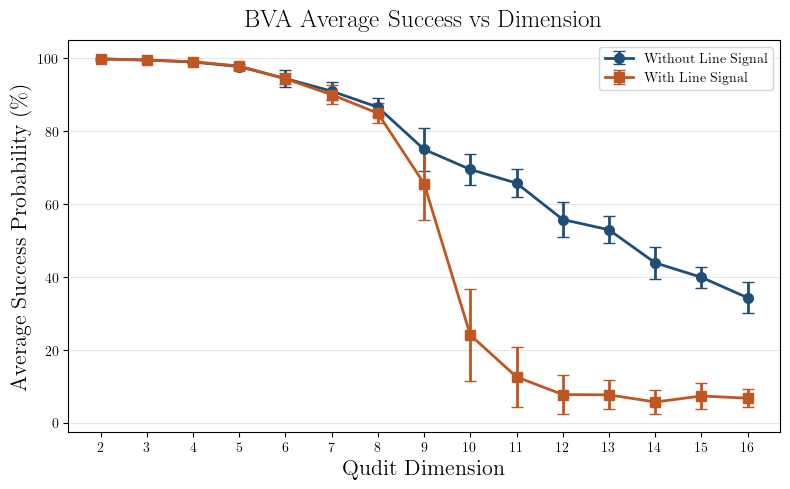

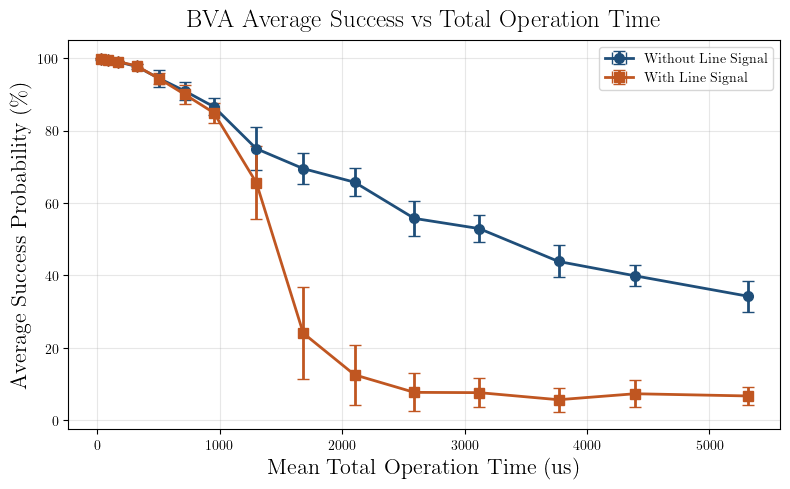

Without Line Signal
  d= 2: mean success =  99.80% , std across hidden strings =   0.26% , mean total operation time =    25.00 us , std time =    0.00 us
  d= 3: mean success =  99.50% , std across hidden strings =   0.08% , mean total operation time =    88.18 us , std time =    0.00 us
  d= 4: mean success =  98.96% , std across hidden strings =   0.29% , mean total operation time =   168.37 us , std time =    0.00 us
  d= 5: mean success =  97.70% , std across hidden strings =   0.80% , mean total operation time =   319.01 us , std time =    0.00 us
  d= 6: mean success =  94.42% , std across hidden strings =   2.32% , mean total operation time =   502.86 us , std time =    0.00 us
  d= 7: mean success =  90.96% , std across hidden strings =   2.55% , mean total operation time =   711.33 us , std time =    0.00 us
  d= 8: mean success =  86.57% , std across hidden strings =   2.39% , mean total operation time =   951.14 us , std time =    0.00 us
  d= 9: mean success =  74.98% , st

In [509]:
if algorithm_mode != "qudit_qft":
    raise ValueError("This dimension-scaling sweep currently assumes algorithm_mode = 'qudit_qft'.")

max_supported_dimension = min(16, max(mappings.keys()) + 1)
dimensions_to_test = list(range(2, max_supported_dimension + 1))
line_noise_settings = [False, True]
sweep_results = {}

for use_line_noise_sweep in line_noise_settings:
    mean_success_by_dimension = []
    std_success_by_dimension = []
    mean_total_operation_time_us = []
    std_total_operation_time_us = []
    all_success_by_dimension = {}
    all_total_operation_time_by_dimension = {}

    for dim_test in dimensions_to_test:
        dim_case_kwargs = {"dimension": dim_test}
        dim_hidden_values = list(range(dim_test))
        dim_success_probabilities = []
        dim_total_operation_times_us = []

        for hidden_value in dim_hidden_values:
            hidden_case = build_bva_case("qudit_qft", hidden_value=hidden_value, **dim_case_kwargs)
            hidden_unitaries = hidden_case["unitaries"]
            hidden_expected_output = hidden_case["expected_output_index"]
            hidden_initial_state = basis_state(0, dim_test)

            hidden_schedule, hidden_final_frame, _ = decompose_unitary_sequence(
                hidden_unitaries,
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
            )
            hidden_couplings = [step['coupling'] for step in hidden_schedule]
            hidden_thetas = [step['theta'] for step in hidden_schedule]
            hidden_phases = [step['phi_programmed'] for step in hidden_schedule]

            hidden_pulse_train = build_transitions_list(mappings, hidden_couplings)
            hidden_pi_times = np.asarray(get_pi_times(hidden_pulse_train), dtype=float)
            hidden_sensitivities = np.asarray(get_values_from_matrix(hidden_pulse_train, sens_matrix), dtype=float)
            hidden_target_state = sequence_target_unitary(hidden_unitaries) @ hidden_initial_state

            hidden_durations_us = pulse_durations_us_from_thetas(hidden_thetas, hidden_pi_times)
            dim_total_operation_times_us.append(np.sum(hidden_durations_us))

            hidden_result = monte_carlo_schedule(
                couplings=hidden_couplings,
                thetas=hidden_thetas,
                programmed_phases=hidden_phases,
                initial_state=hidden_initial_state,
                pulse_sensitivities_mhz_per_g=hidden_sensitivities,
                default_pi_time_us=default_pi_time_us,
                per_pulse_pi_time_us=hidden_pi_times,
                final_frame=wrap_frame(hidden_final_frame),
                apply_final_frame=apply_final_frame,
                use_line_noise=use_line_noise_sweep,
                line_model=line_model,
                line_reference=line_reference,
                num_shots=num_shots,
                rng_seed=None if rng_seed is None else int(rng_seed) + 1000 * dim_test + hidden_value + 100000 * int(use_line_noise_sweep),
                calibration_scale=calibration_scale,
                magnetic_scale=magnetic_scale,
                laser_scale=laser_scale,
                calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
                calibration_noise_sigma_hz=calibration_noise_sigma_hz,
                magnetic_field_std_g=magnetic_field_std_g,
                laser_gaussian_T_s=laser_gaussian_T_s,
                laser_lorentzian_L_s=laser_lorentzian_L_s,
                voigt_x_min_hz=voigt_x_min_hz,
                voigt_x_max_hz=voigt_x_max_hz,
                voigt_num_points=voigt_num_points,
                rabi_frequency_std_fraction=rabi_frequency_std_fraction,
                line_signal_noise_std_g=line_signal_noise_std_g,
                target_state=hidden_target_state,
            )

            dim_success_probabilities.append(hidden_result['mean_populations'][hidden_expected_output])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        dim_total_operation_times_us = np.asarray(dim_total_operation_times_us, dtype=float)
        all_success_by_dimension[dim_test] = dim_success_probabilities
        all_total_operation_time_by_dimension[dim_test] = dim_total_operation_times_us
        mean_success_by_dimension.append(np.mean(dim_success_probabilities))
        std_success_by_dimension.append(np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0)
        mean_total_operation_time_us.append(np.mean(dim_total_operation_times_us))
        std_total_operation_time_us.append(np.std(dim_total_operation_times_us, ddof=1) if len(dim_total_operation_times_us) > 1 else 0.0)

    sweep_results[use_line_noise_sweep] = {
        'mean_success_by_dimension': np.asarray(mean_success_by_dimension, dtype=float),
        'std_success_by_dimension': np.asarray(std_success_by_dimension, dtype=float),
        'mean_total_operation_time_us': np.asarray(mean_total_operation_time_us, dtype=float),
        'std_total_operation_time_us': np.asarray(std_total_operation_time_us, dtype=float),
        'all_success_by_dimension': all_success_by_dimension,
        'all_total_operation_time_by_dimension': all_total_operation_time_by_dimension,
    }

plot_styles = {
    False: {'label': 'Without Line Signal', 'color': '#1f4e79', 'marker': 'o'},
    True: {'label': 'With Line Signal', 'color': '#c05621', 'marker': 's'},
}

fig, ax = plt.subplots(figsize=(8, 5))
for use_line_noise_sweep in line_noise_settings:
    style = plot_styles[use_line_noise_sweep]
    means = 100.0 * sweep_results[use_line_noise_sweep]['mean_success_by_dimension']
    stds = 100.0 * sweep_results[use_line_noise_sweep]['std_success_by_dimension']
    ax.errorbar(
        dimensions_to_test,
        means,
        yerr=stds,
        fmt=f"{style['marker']}-",
        color=style['color'],
        ecolor=style['color'],
        capsize=4,
        linewidth=2,
        markersize=7,
        label=style['label'],
    )

ax.set_xlabel('Qudit Dimension', fontsize=16)
ax.set_ylabel('Average Success Probability (\\%)', fontsize=16)
ax.set_title('BVA Average Success vs Dimension', fontsize=18, pad=10)
ax.set_xticks(dimensions_to_test)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for use_line_noise_sweep in line_noise_settings:
    style = plot_styles[use_line_noise_sweep]
    mean_times = sweep_results[use_line_noise_sweep]['mean_total_operation_time_us']
    std_times = sweep_results[use_line_noise_sweep]['std_total_operation_time_us']
    means = 100.0 * sweep_results[use_line_noise_sweep]['mean_success_by_dimension']
    stds = 100.0 * sweep_results[use_line_noise_sweep]['std_success_by_dimension']
    ax.errorbar(
        mean_times,
        means,
        xerr=std_times,
        yerr=stds,
        fmt=f"{style['marker']}-",
        color=style['color'],
        ecolor=style['color'],
        capsize=4,
        linewidth=2,
        markersize=7,
        label=style['label'],
    )

ax.set_xlabel('Mean Total Operation Time (us)', fontsize=16)
ax.set_ylabel('Average Success Probability (\\%)', fontsize=16)
ax.set_title('BVA Average Success vs Total Operation Time', fontsize=18, pad=10)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for use_line_noise_sweep in line_noise_settings:
    label = plot_styles[use_line_noise_sweep]['label']
    means = sweep_results[use_line_noise_sweep]['mean_success_by_dimension']
    stds = sweep_results[use_line_noise_sweep]['std_success_by_dimension']
    mean_times = sweep_results[use_line_noise_sweep]['mean_total_operation_time_us']
    std_times = sweep_results[use_line_noise_sweep]['std_total_operation_time_us']
    print(label)
    for dim_test, mean_success, std_success, mean_time, std_time in zip(dimensions_to_test, means, stds, mean_times, std_times):
        print(
            f'  d={dim_test:2d}: mean success = {100.0 * mean_success:6.2f}% , '
            f'std across hidden strings = {100.0 * std_success:6.2f}% , '
            f'mean total operation time = {mean_time:8.2f} us , std time = {std_time:7.2f} us'
        )


Running Without Line Signal...
Running With Line Signal...
Running Magnetic Field Only...
Running Laser Noise Only...
Running Calibration Noise Only...
Running Pulse Time Errors Only...
Running Line Signal Only...


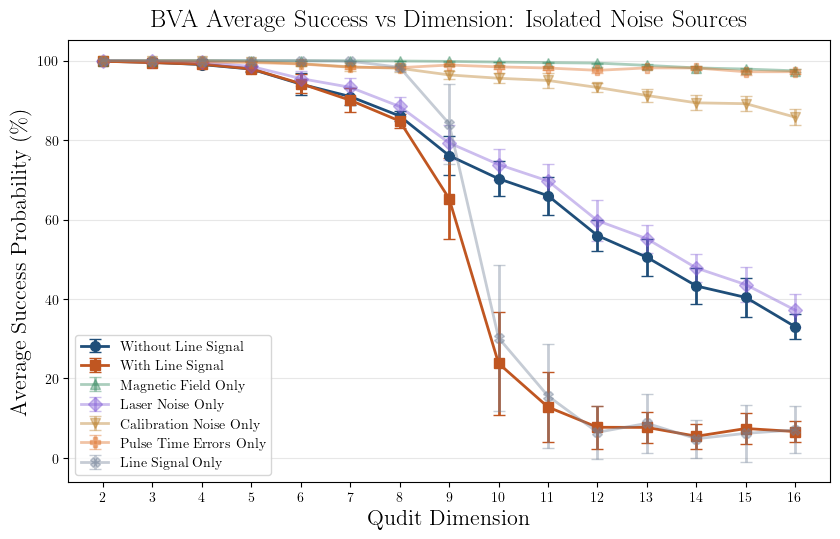

Cache file: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\bva_dimension_isolated_noise_sources.npz
Loaded from saved run: True
Without Line Signal
  d= 2: mean success =  99.84% , std across hidden strings =   0.21%
  d= 3: mean success =  99.56% , std across hidden strings =   0.08%
  d= 4: mean success =  99.00% , std across hidden strings =   0.20%
  d= 5: mean success =  97.86% , std across hidden strings =   0.82%
  d= 6: mean success =  94.08% , std across hidden strings =   2.69%
  d= 7: mean success =  90.96% , std across hidden strings =   2.15%
  d= 8: mean success =  86.07% , std across hidden strings =   1.16%
  d= 9: mean success =  76.09% , std across hidden strings =   4.91%
  d=10: mean success =  70.28% , std across hidden strings =   4.44%
  d=11: mean success =  65.98% , std across hidden strings =   4.72%
  d=12: mean success =  55.97% , std across hidden strings =   3.94%
  d=13: mean success =  50.49% , std across hidden strings 

In [ ]:
from pathlib import Path

if algorithm_mode != "qudit_qft":
    raise ValueError("This dimension-scaling sweep currently assumes algorithm_mode = 'qudit_qft'.")

isolated_noise_sources_cache_path = Path(
    r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\bva_dimension_isolated_noise_sources.npz"
)
rerun_isolated_noise_sources = False

max_supported_dimension = min(16, max(mappings.keys()) + 1)
dimensions_to_test = list(range(2, max_supported_dimension + 1))
max_hidden_count = max(dimensions_to_test)

curve_specs = {
    'Without Line Signal': {
        'use_line_noise': False,
        'calibration_scale': calibration_scale,
        'magnetic_scale': magnetic_scale,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#1f4e79',
        'marker': 'o',
        'alpha': 1.0,
    },
    'With Line Signal': {
        'use_line_noise': True,
        'calibration_scale': calibration_scale,
        'magnetic_scale': magnetic_scale,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#c05621',
        'marker': 's',
        'alpha': 1.0,
    },
    'Magnetic Field Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': magnetic_scale,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#2f855a',
        'marker': '^',
        'alpha': 0.4,
    },
    'Laser Noise Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#805ad5',
        'marker': 'D',
        'alpha': 0.4,
    },
    'Calibration Noise Only': {
        'use_line_noise': False,
        'calibration_scale': calibration_scale,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#b7791f',
        'marker': 'v',
        'alpha': 0.4,
    },
    'Pulse Time Errors Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': 0.0,
        'color': '#dd6b20',
        'marker': 'P',
        'alpha': 0.4,
    },
    'Line Signal Only': {
        'use_line_noise': True,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#718096',
        'marker': 'X',
        'alpha': 0.4,
    },
}
curve_order = list(curve_specs.keys())

def curve_cache_key(label):
    return label.lower().replace(' ', '_')

def run_dimension_success_curve(curve_cfg, curve_seed_offset):
    mean_success_by_dimension = []
    std_success_by_dimension = []
    all_success_padded = []

    for dim_test in dimensions_to_test:
        dim_case_kwargs = {'dimension': dim_test}
        dim_hidden_values = list(range(dim_test))
        dim_success_probabilities = []

        for hidden_value in dim_hidden_values:
            hidden_case = build_bva_case('qudit_qft', hidden_value=hidden_value, **dim_case_kwargs)
            hidden_unitaries = hidden_case['unitaries']
            hidden_expected_output = hidden_case['expected_output_index']
            hidden_initial_state = basis_state(0, dim_test)

            hidden_schedule, hidden_final_frame, _ = decompose_unitary_sequence(
                hidden_unitaries,
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
            )
            hidden_couplings = [step['coupling'] for step in hidden_schedule]
            hidden_thetas = [step['theta'] for step in hidden_schedule]
            hidden_phases = [step['phi_programmed'] for step in hidden_schedule]

            hidden_pulse_train = build_transitions_list(mappings, hidden_couplings)
            hidden_pi_times = np.asarray(get_pi_times(hidden_pulse_train), dtype=float)
            hidden_sensitivities = np.asarray(get_values_from_matrix(hidden_pulse_train, sens_matrix), dtype=float)
            hidden_target_state = sequence_target_unitary(hidden_unitaries) @ hidden_initial_state

            hidden_result = monte_carlo_schedule(
                couplings=hidden_couplings,
                thetas=hidden_thetas,
                programmed_phases=hidden_phases,
                initial_state=hidden_initial_state,
                pulse_sensitivities_mhz_per_g=hidden_sensitivities,
                default_pi_time_us=default_pi_time_us,
                per_pulse_pi_time_us=hidden_pi_times,
                final_frame=wrap_frame(hidden_final_frame),
                apply_final_frame=apply_final_frame,
                use_line_noise=curve_cfg['use_line_noise'],
                line_model=line_model,
                line_reference=line_reference,
                num_shots=num_shots,
                rng_seed=None if rng_seed is None else int(rng_seed) + 1000 * dim_test + hidden_value + 100000 * curve_seed_offset,
                calibration_scale=curve_cfg['calibration_scale'],
                magnetic_scale=curve_cfg['magnetic_scale'],
                laser_scale=curve_cfg['laser_scale'],
                calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
                calibration_noise_sigma_hz=calibration_noise_sigma_hz,
                magnetic_field_std_g=magnetic_field_std_g,
                laser_gaussian_T_s=laser_gaussian_T_s,
                laser_lorentzian_L_s=laser_lorentzian_L_s,
                voigt_x_min_hz=voigt_x_min_hz,
                voigt_x_max_hz=voigt_x_max_hz,
                voigt_num_points=voigt_num_points,
                rabi_frequency_std_fraction=curve_cfg['rabi_frequency_std_fraction'],
                line_signal_noise_std_g=curve_cfg['line_signal_noise_std_g'],
                target_state=hidden_target_state,
            )

            dim_success_probabilities.append(hidden_result['mean_populations'][hidden_expected_output])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        padded_success = np.full(max_hidden_count, np.nan, dtype=float)
        padded_success[:len(dim_success_probabilities)] = dim_success_probabilities
        all_success_padded.append(padded_success)

        mean_success_by_dimension.append(np.mean(dim_success_probabilities))
        std_success_by_dimension.append(np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0)

    return {
        'mean_success_by_dimension': np.asarray(mean_success_by_dimension, dtype=float),
        'std_success_by_dimension': np.asarray(std_success_by_dimension, dtype=float),
        'all_success_padded': np.asarray(all_success_padded, dtype=float),
    }

if rerun_isolated_noise_sources or not isolated_noise_sources_cache_path.exists():
    isolated_noise_results = {}
    cache_arrays = {
        'dimensions_to_test': np.asarray(dimensions_to_test, dtype=int),
        'curve_names': np.asarray(curve_order, dtype='<U64'),
    }

    for curve_index, curve_name in enumerate(curve_order):
        print(f'Running {curve_name}...')
        curve_result = run_dimension_success_curve(curve_specs[curve_name], curve_index)
        isolated_noise_results[curve_name] = curve_result
        key = curve_cache_key(curve_name)
        cache_arrays[f'{key}_mean_success_by_dimension'] = curve_result['mean_success_by_dimension']
        cache_arrays[f'{key}_std_success_by_dimension'] = curve_result['std_success_by_dimension']
        cache_arrays[f'{key}_all_success_padded'] = curve_result['all_success_padded']

    np.savez_compressed(isolated_noise_sources_cache_path, **cache_arrays)
else:
    cache_arrays = np.load(isolated_noise_sources_cache_path)
    cached_curve_names = [str(name) for name in cache_arrays['curve_names']]
    if cached_curve_names != curve_order:
        raise ValueError('Cached isolated-noise results do not match the current curve definitions. Set rerun_isolated_noise_sources = True.')

    dimensions_to_test = cache_arrays['dimensions_to_test'].astype(int).tolist()
    isolated_noise_results = {}
    for curve_name in curve_order:
        key = curve_cache_key(curve_name)
        isolated_noise_results[curve_name] = {
            'mean_success_by_dimension': np.asarray(cache_arrays[f'{key}_mean_success_by_dimension'], dtype=float),
            'std_success_by_dimension': np.asarray(cache_arrays[f'{key}_std_success_by_dimension'], dtype=float),
            'all_success_padded': np.asarray(cache_arrays[f'{key}_all_success_padded'], dtype=float),
        }

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for curve_name in curve_order:
    style = curve_specs[curve_name]
    means = 100.0 * isolated_noise_results[curve_name]['mean_success_by_dimension']
    stds = 100.0 * isolated_noise_results[curve_name]['std_success_by_dimension']
    ax.errorbar(
        dimensions_to_test,
        means,
        yerr=stds,
        fmt=f"{style['marker']}-",
        color=style['color'],
        ecolor=style['color'],
        capsize=4,
        linewidth=2,
        markersize=7,
        alpha=style['alpha'],
        label=curve_name,
    )

ax.set_xlabel('Qudit Dimension', fontsize=16)
ax.set_ylabel('Average Success Probability (\\%)', fontsize=16)
ax.set_title('BVA Average Success vs Dimension: Isolated Noise Sources', fontsize=18, pad=10)
ax.set_xticks(dimensions_to_test)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Cache file: {isolated_noise_sources_cache_path}')
print(f'Loaded from saved run: {not rerun_isolated_noise_sources and isolated_noise_sources_cache_path.exists()}')
for curve_name in curve_order:
    print(curve_name)
    means = isolated_noise_results[curve_name]['mean_success_by_dimension']
    stds = isolated_noise_results[curve_name]['std_success_by_dimension']
    for dim_test, mean_success, std_success in zip(dimensions_to_test, means, stds):
        print(f'  d={dim_test:2d}: mean success = {100.0 * mean_success:6.2f}% , std across hidden strings = {100.0 * std_success:6.2f}%')
